# Tutorial 10 — Hierarchical Regression and Correlation
## Statistical Computation and Analysis 2026-2

This tutorial has two parts:

1. **Hierarchical regression with the radon data** — multiple regression, hierarchical regression with county-level intercepts, and short LOO comparison.
2. **Correlation and covariance** — regression versus correlation, Pearson's \(r\), population correlation \(\rho\), \(\rho^2\), the covariance matrix, and a simple Bayesian bivariate Normal correlation model.

The notebook follows the course workflow: inspect data, define the model, check prior predictive implications, sample, inspect diagnostics, interpret the posterior, check posterior predictive behavior, and compare models when relevant.

In [1]:
# ------------------------------------------------------------
# Package setup
# ------------------------------------------------------------
# Course-compatible package versions.
# If this cell installs or changes packages, restart the runtime
# and run the notebook again from the beginning.
# ------------------------------------------------------------

import sys
import subprocess
from importlib.metadata import version, PackageNotFoundError
from packaging.version import Version

IS_COLAB = "google.colab" in sys.modules

COURSE_PACKAGE_VERSIONS = {
    "arviz": "0.22.0",
    "matplotlib": "3.10.0",
    "numpy": "2.0.2",
    "pandas": "2.2.2",
    "pymc": "5.28.4",
    "scipy": "1.16.3",
    "seaborn": "0.13.2",
}

EXTRA_PACKAGES = {"bambi": None, "preliz": None, "packaging": None}
packages_to_install = []

for package_name, required_version in COURSE_PACKAGE_VERSIONS.items():
    try:
        current_version = version(package_name)
        print(f"{package_name:10s}: {current_version}")
        if Version(current_version) != Version(required_version):
            packages_to_install.append(f"{package_name}=={required_version}")
    except PackageNotFoundError:
        packages_to_install.append(f"{package_name}=={required_version}")

for package_name in EXTRA_PACKAGES:
    try:
        current_version = version(package_name)
        print(f"{package_name:10s}: {current_version}")
    except PackageNotFoundError:
        packages_to_install.append(package_name)

if packages_to_install:
    print("Installing/updating packages:")
    for package in packages_to_install:
        print(" -", package)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages_to_install])
    print("Packages were installed or changed. Restart the runtime now, then run all cells again.")
    raise SystemExit("Restart the runtime, then run all cells again from the beginning.")
else:
    print("All required course package versions are already installed.")

arviz     : 0.22.0
matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.2.2
pymc      : 5.28.4
scipy     : 1.16.3
seaborn   : 0.13.2
bambi     : 0.17.2
preliz    : 0.24.0
packaging : 26.2
All required course package versions are already installed.


In [2]:
# ------------------------------------------------------------
# Imports and global settings
# ------------------------------------------------------------

from pathlib import Path
import warnings

import arviz as az
import bambi as bmb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
import scipy
from scipy import stats
import seaborn as sns
import pytensor.tensor as pt

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"arviz     : {az.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"numpy     : {np.__version__}")
print(f"pandas    : {pd.__version__}")
print(f"pymc      : {pm.__version__}")
print(f"scipy     : {scipy.__version__}")
print(f"seaborn   : {sns.__version__}")
print(f"bambi     : {bmb.__version__}")
print(f"preliz    : {pz.__version__}")

assert az.__version__ == "0.22.0"
assert matplotlib.__version__ == "3.10.0"
assert np.__version__ == "2.0.2"
assert pd.__version__ == "2.2.2"
assert pm.__version__ == "5.28.4"
assert scipy.__version__ == "1.16.3"
assert sns.__version__ == "0.13.2"

RANDOM_SEED = 17
rng = np.random.default_rng(RANDOM_SEED)
HDI_MASS = 0.94

BAYES_DRAWS = 1000
BAYES_TUNE = 1000
BAYES_CHAINS = 4
TARGET_ACCEPT = 0.9

az.style.use("arviz-whitegrid")
sns.set_context("notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Colab detected:", IS_COLAB)

arviz     : 0.22.0
matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.2.2
pymc      : 5.28.4
scipy     : 1.16.3
seaborn   : 0.13.2
bambi     : 0.17.2
preliz    : 0.24.0
Colab detected: True


# Helper functions

In [3]:
def load_csv_or_upload(filename):
    # Read a CSV file from the current session. In Colab, ask for upload if missing.
    search_dirs = [Path("."), Path("data"), Path("Data"), Path("/content"), Path("/content/data"), Path("/mnt/data")]
    for directory in search_dirs:
        candidate = directory / filename
        if candidate.exists():
            print(f"Using existing file: {candidate}")
            return pd.read_csv(candidate)
    if IS_COLAB:
        from google.colab import files
        print(f"{filename} was not found in the current Colab session. Please upload {filename}.")
        uploaded = files.upload()
        uploaded_filename = filename if filename in uploaded else list(uploaded.keys())[0]
        print(f"Using uploaded file: {uploaded_filename}")
        return pd.read_csv(uploaded_filename)
    raise FileNotFoundError(f"Could not find {filename}. Put it in the notebook folder and run again.")


def standardize(series):
    return (series - series.mean()) / series.std(ddof=1)


def diagnostics_table(idata, var_names=None):
    return az.summary(idata, var_names=var_names, kind="diagnostics").round(2)


def posterior_summary_table(idata, var_names=None):
    return az.summary(idata, var_names=var_names, kind="stats", hdi_prob=HDI_MASS).round(3)


def print_divergences(idata, model_name):
    if "sample_stats" not in idata.groups():
        print(f"No sample_stats group found for {model_name}.")
        return np.nan
    n_divergences = int(idata.sample_stats["diverging"].sum().values)
    print(f"Number of divergences in {model_name}: {n_divergences}")
    return n_divergences


def plot_cumulative_ppc(idata, group, title, xlabel, num_pp_samples=100):
    az.plot_ppc(
        idata,
        group=group,
        observed=True,
        kind="cumulative",
        num_pp_samples=num_pp_samples,
        random_seed=RANDOM_SEED,
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.show()


def plot_regression_ppc(idata, title, xlabel="log radon", num_pp_samples=100):
    az.plot_ppc(
        idata,
        group="posterior",
        observed=True,
        num_pp_samples=num_pp_samples,
        random_seed=RANDOM_SEED,
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.show()

# Load and prepare the radon dataset

The dataset contains household-level radon measurements from Minnesota. In the first part, the response is `log_radon`. We use:

- `basement`: whether the house has a basement (`Y`/`N`).
- `Uppm`: county-level uranium measure, standardized as `uranium_z`.
- `county`: county name, used as the grouping variable in the hierarchical model.

In the second part, we use `log_radon` and `uranium_z` as two continuous measurements to demonstrate correlation. This is an association model, not a causal claim.

In [4]:
radon_raw = load_csv_or_upload("radon.csv")
print("Dataset shape:", radon_raw.shape)
display(radon_raw.head())
print("Columns:")
print(radon_raw.columns.tolist())

radon.csv was not found in the current Colab session. Please upload radon.csv.


Saving radon.csv to radon.csv
Using uploaded file: radon.csv
Dataset shape: (919, 30)


,Unnamed: 0,idnum,state,state2,stfips,zip,region,typebldg,floor,room,...,pcterr,adjwt,dupflag,zipflag,cntyfips,county,fips,Uppm,county_code,log_radon
0,0,5081.0,MN,MN,27.0,55735,5.0,1.0,1.0,3.0,...,9.7,1146.499190,1.0,0.0,1.0,AITKIN,27001.0,0.502054,0,0.832909
1,1,5082.0,MN,MN,27.0,55748,5.0,1.0,0.0,4.0,...,14.5,471.366223,0.0,0.0,1.0,AITKIN,27001.0,0.502054,0,0.832909
2,2,5083.0,MN,MN,27.0,55748,5.0,1.0,0.0,4.0,...,9.6,433.316718,0.0,0.0,1.0,AITKIN,27001.0,0.502054,0,1.098612
3,3,5084.0,MN,MN,27.0,56469,5.0,1.0,0.0,4.0,...,24.3,461.623670,0.0,0.0,1.0,AITKIN,27001.0,0.502054,0,0.095310
4,4,5085.0,MN,MN,27.0,55011,3.0,1.0,0.0,4.0,...,13.8,433.316718,0.0,0.0,3.0,ANOKA,27003.0,0.428565,1,1.163151


Columns:
['Unnamed: 0', 'idnum', 'state', 'state2', 'stfips', 'zip', 'region', 'typebldg', 'floor', 'room', 'basement', 'windoor', 'rep', 'stratum', 'wave', 'starttm', 'stoptm', 'startdt', 'stopdt', 'activity', 'pcterr', 'adjwt', 'dupflag', 'zipflag', 'cntyfips', 'county', 'fips', 'Uppm', 'county_code', 'log_radon']


In [5]:
required_columns = ["log_radon", "basement", "Uppm", "county"]
missing_columns = [col for col in required_columns if col not in radon_raw.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

radon = radon_raw[required_columns].copy()
radon["basement"] = radon["basement"].astype(str).str.strip()
radon = radon[radon["basement"].isin(["Y", "N"])].copy()

radon["log_radon"] = pd.to_numeric(radon["log_radon"], errors="coerce")
radon["Uppm"] = pd.to_numeric(radon["Uppm"], errors="coerce")
radon["county"] = radon["county"].astype(str).str.strip()

n_before = len(radon)
radon = radon.dropna(subset=["log_radon", "Uppm", "county", "basement"]).reset_index(drop=True)
n_after = len(radon)

radon["uranium_z"] = standardize(radon["Uppm"])
radon["log_radon_z"] = standardize(radon["log_radon"])
radon["basement"] = pd.Categorical(radon["basement"], categories=["N", "Y"])

print(f"Rows before dropping missing values: {n_before}")
print(f"Rows after cleaning               : {n_after}")
print(f"Number of counties                : {radon['county'].nunique()}")
print("Basement counts:")
print(radon["basement"].value_counts())

display(radon.head())
display(radon[["log_radon", "Uppm", "uranium_z", "log_radon_z"]].describe().T.round(3))

Rows before dropping missing values: 878
Rows after cleaning               : 878
Number of counties                : 85
Basement counts:
basement
Y    819
N     59
Name: count, dtype: int64


,log_radon,basement,Uppm,county,uranium_z,log_radon_z
0,0.832909,N,0.502054,AITKIN,-1.348424,-0.525273
1,0.832909,Y,0.502054,AITKIN,-1.348424,-0.525273
2,1.098612,Y,0.502054,AITKIN,-1.348424,-0.201600
3,0.095310,Y,0.502054,AITKIN,-1.348424,-1.423797
4,1.163151,Y,0.428565,ANOKA,-1.577700,-0.122981


,count,mean,std,min,25%,50%,75%,max
log_radon,878.0,1.264,0.821,-2.303,0.693,1.308,1.832,3.877
Uppm,878.0,0.934,0.321,0.414,0.622,0.908,1.213,1.696
uranium_z,878.0,0.000,1.000,-1.623,-0.974,-0.082,0.870,2.375
log_radon_z,878.0,0.000,1.000,-4.345,-0.696,0.054,0.692,3.183


# Part 1 — Multiple regression and hierarchical regression

Houses are nested within counties. A regular multiple regression can include house-level predictors, but it does not represent county-level dependence. A hierarchical regression adds a county-level intercept.

We compare two models:

**Model 1: Multiple regression**

\[
\mu_i = \beta_0 + \beta_1\,basement_i + \beta_2\,uranium_{z,i}
\]

**Model 2: Hierarchical regression with county intercepts**

\[
\mu_i = \beta_0 + \beta_1\,basement_i + \beta_2\,uranium_{z,i} + u_{county[i]}
\]

\[
u_j \sim \operatorname{Normal}(0, \sigma_{county})
\]

The comparison asks whether accounting for county-level structure improves expected out-of-sample prediction.

## 1.1 Inspect the regression data

/tmp/ipykernel_1018/73590721.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


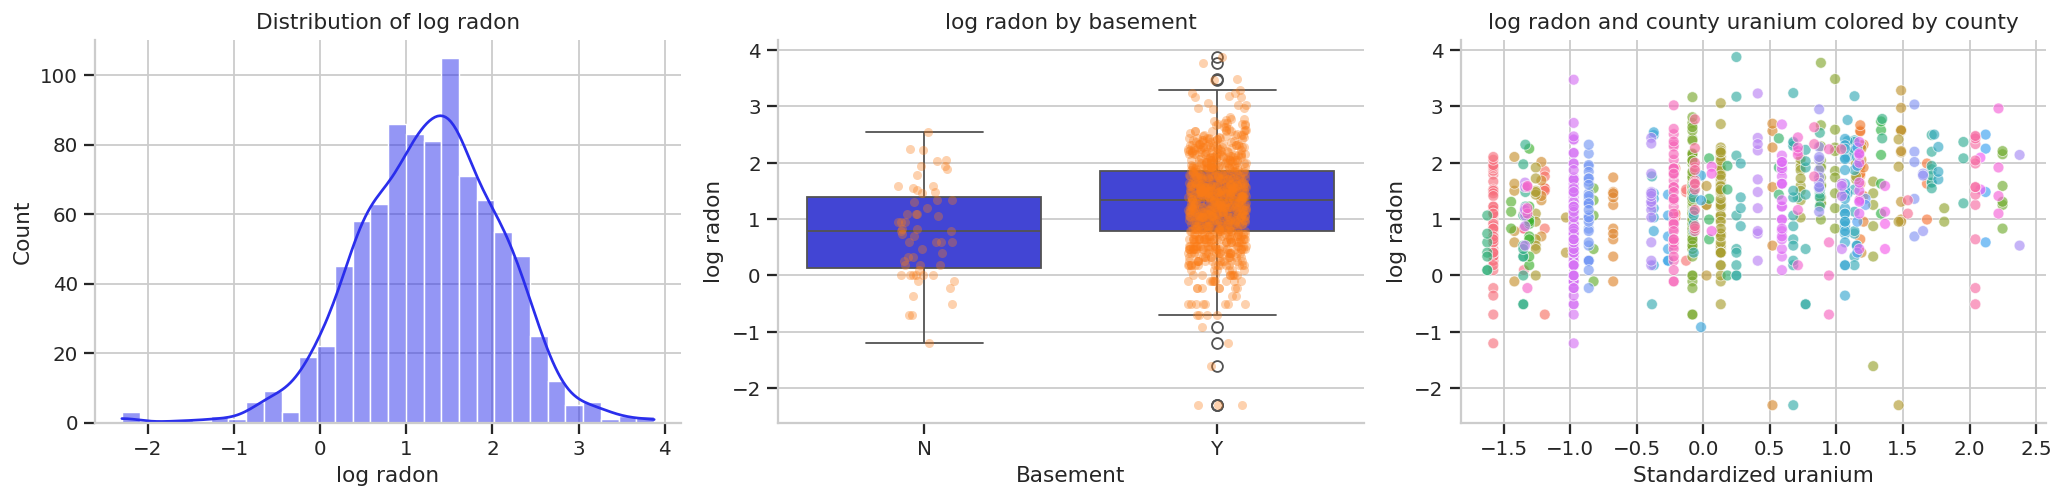

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(radon["log_radon"], bins=30, kde=True, ax=axes[0], edgecolor="white")
axes[0].set_title("Distribution of log radon")
axes[0].set_xlabel("log radon")
axes[0].set_ylabel("Count")

sns.boxplot(data=radon, x="basement", y="log_radon", ax=axes[1])
sns.stripplot(data=radon, x="basement", y="log_radon", ax=axes[1], alpha=0.35, jitter=True)
axes[1].set_title("log radon by basement")
axes[1].set_xlabel("Basement")
axes[1].set_ylabel("log radon")

sns.scatterplot(data=radon, x="uranium_z", y="log_radon", hue="county", legend=None, ax=axes[2], alpha=0.65)
axes[2].set_title("log radon and county uranium colored by county")
axes[2].set_xlabel("Standardized uranium")
axes[2].set_ylabel("log radon")
# axes[2].legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

,n_houses,mean_log_radon,mean_uranium
county,,,
LAKE,9,0.410,0.501
KOOCHICHING,7,0.475,0.414
WASECA,4,0.534,1.237
MILLE LACS,2,0.624,0.811
FARIBAULT,6,0.664,1.343


,n_houses,mean_log_radon,mean_uranium
county,,,
NICOLLET,4,2.178,1.282
WATONWAN,3,2.241,1.201
WILKIN,1,2.241,1.266
MURRAY,1,2.501,1.490
LAC QUI PARLE,2,2.606,1.365


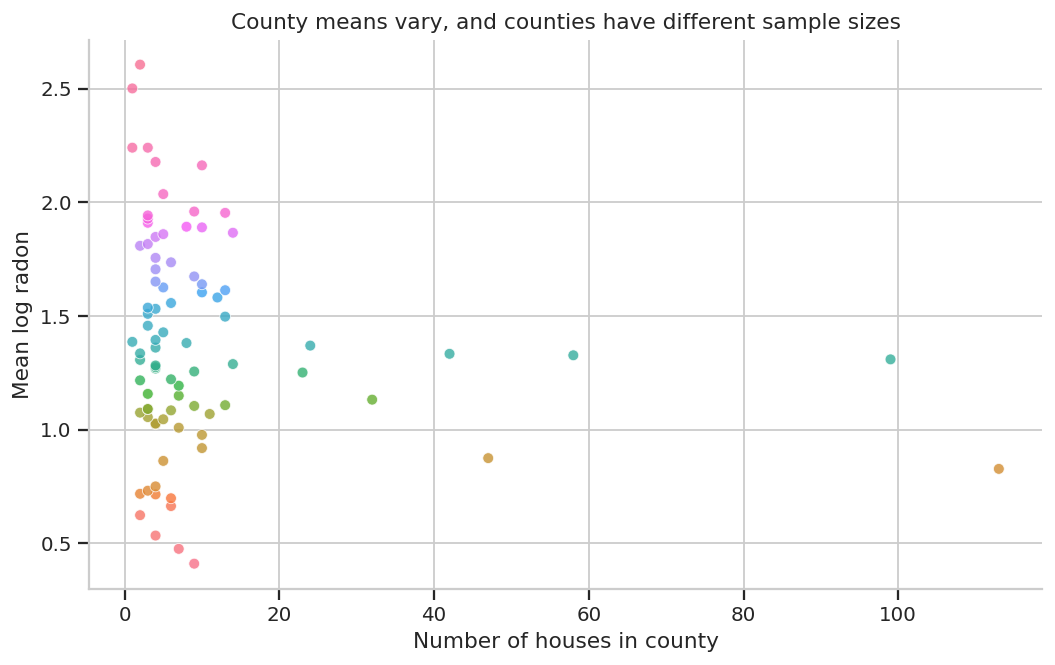

In [15]:
county_summary = (
    radon.groupby("county", observed=True)
    .agg(n_houses=("log_radon", "size"), mean_log_radon=("log_radon", "mean"), mean_uranium=("Uppm", "mean"))
    .sort_values("mean_log_radon")
)

display(county_summary.head().round(3))
display(county_summary.tail().round(3))

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=county_summary, x="n_houses", y="mean_log_radon", hue="county", legend=None, ax=ax, alpha=0.8)
# ax.set_xscale("log")
ax.set_title("County means vary, and counties have different sample sizes")
ax.set_xlabel("Number of houses in county") #  (log scale)
ax.set_ylabel("Mean log radon")
plt.show()

## 1.2 Model 1 — Multiple regression

Formula:

```text
log_radon ~ basement + uranium_z
```

Mean equation:

\[
\mu_i = \beta_0 + \beta_1 basement_i + \beta_2 uranium_{z,i}
\]

This model treats the rows as conditionally independent after accounting for basement and county-level uranium. It does not include a county-level intercept.

In [16]:
# If you want to chhoose your own priors
radon_regression_priors = {
    "Intercept": bmb.Prior("Normal", mu=1.2, sigma=1.0),
    "basement": bmb.Prior("Normal", mu=0, sigma=1.0),
    "uranium_z": bmb.Prior("Normal", mu=0, sigma=1.0),
    "sigma": bmb.Prior("HalfNormal", sigma=1.0),
}

In [17]:
multiple_model = bmb.Model(
    "log_radon ~ basement + uranium_z",
    data=radon,
    family="gaussian",
    priors=radon_regression_priors,
)
print(multiple_model)

       Formula: log_radon ~ basement + uranium_z
        Family: gaussian
          Link: mu = identity
  Observations: 878
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 1.2, sigma: 1.0)
            basement ~ Normal(mu: 0.0, sigma: 1.0)
            uranium_z ~ Normal(mu: 0.0, sigma: 1.0)
        
        Auxiliary parameters
            sigma ~ HalfNormal(sigma: 1.0)


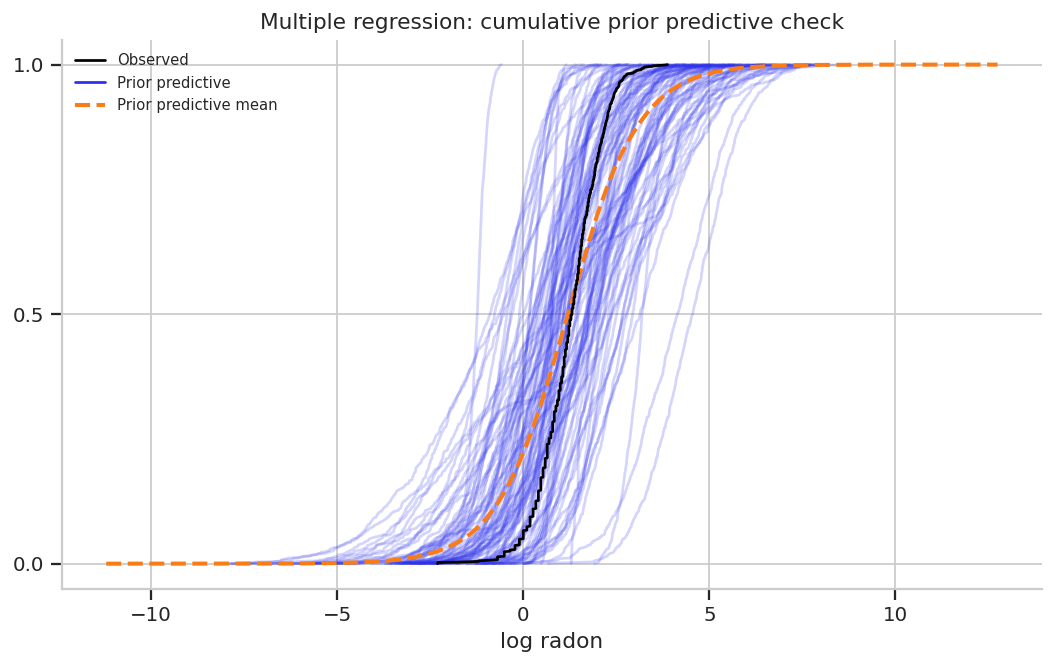

In [18]:
multiple_model.build()
multiple_prior = multiple_model.prior_predictive(draws=1000, random_seed=RANDOM_SEED)
plot_cumulative_ppc(
    multiple_prior,
    group="prior",
    title="Multiple regression: cumulative prior predictive check",
    xlabel="log radon",
)

In [19]:
idata_multiple = multiple_model.fit(
    draws=BAYES_DRAWS,
    tune=BAYES_TUNE,
    chains=BAYES_CHAINS,
    random_seed=RANDOM_SEED,
    target_accept=TARGET_ACCEPT,
    idata_kwargs={"log_likelihood": True},
)
print(idata_multiple)

Output()

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data


Number of divergences in Multiple regression: 0


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.0,0.0,4301.0,3202.0,1.0
basement[Y],0.0,0.0,4319.0,3284.0,1.0
uranium_z,0.0,0.0,4215.0,2597.0,1.0
sigma,0.0,0.0,4348.0,3068.0,1.0


,mean,sd,hdi_3%,hdi_97%
Intercept,0.838,0.097,0.662,1.025
basement[Y],0.456,0.102,0.259,0.640
uranium_z,0.259,0.027,0.207,0.309
sigma,0.770,0.018,0.735,0.805


/tmp/ipykernel_1018/3055384766.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


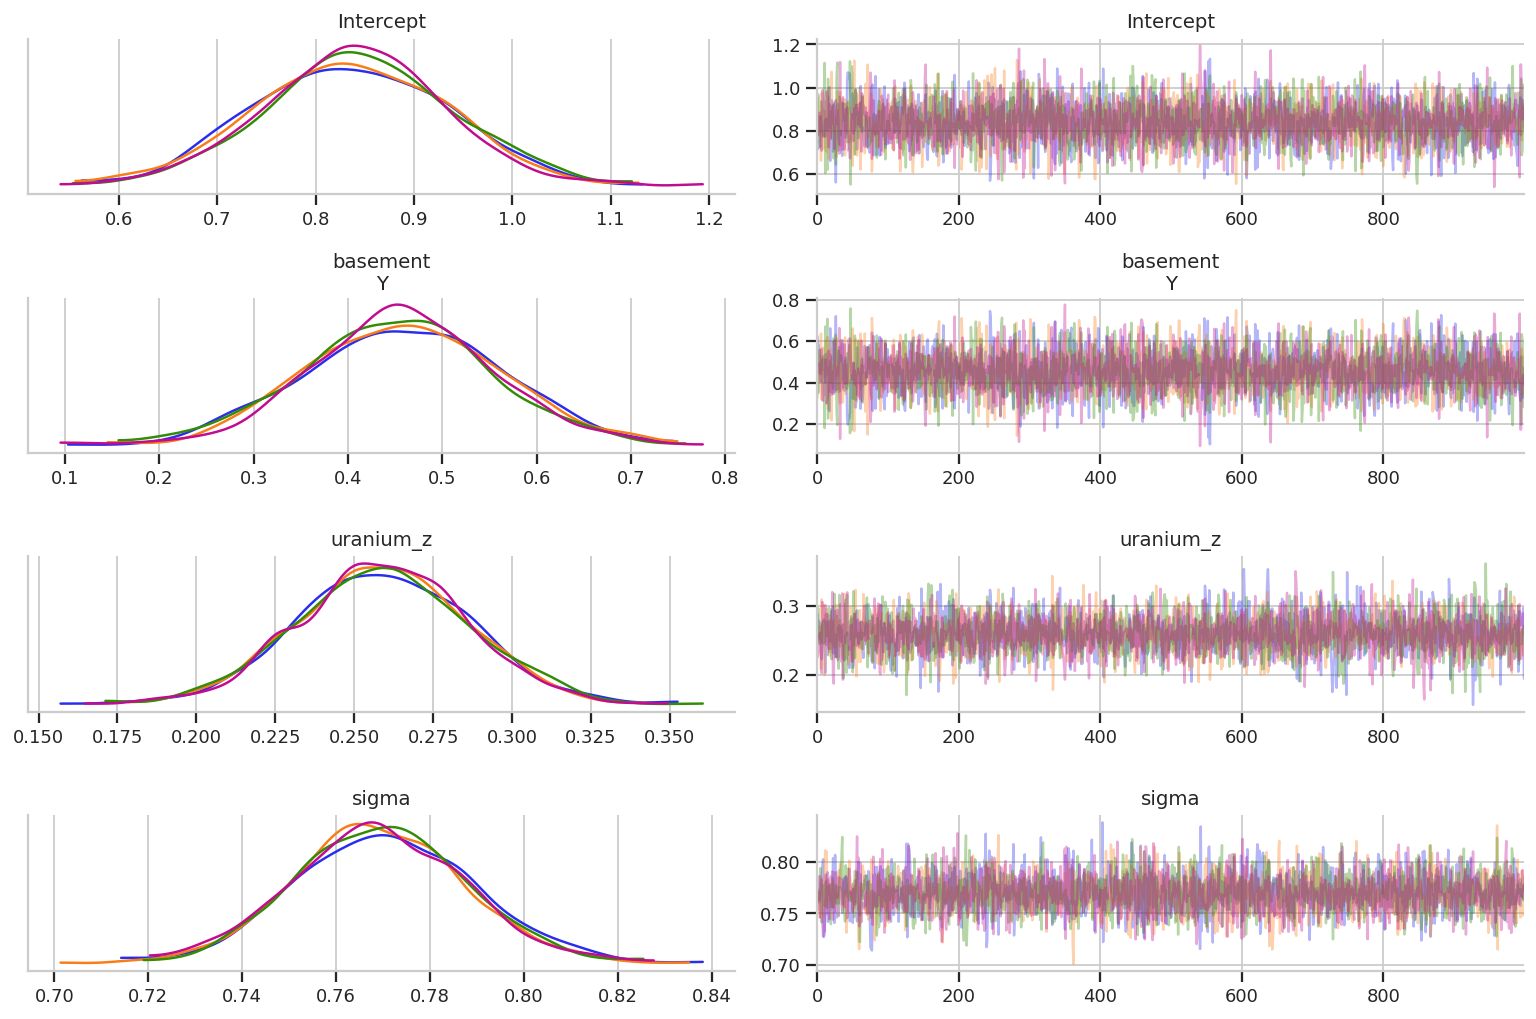

In [20]:
print_divergences(idata_multiple, "Multiple regression")

display(diagnostics_table(idata_multiple, var_names=["Intercept", "basement", "uranium_z", "sigma"]))
display(posterior_summary_table(idata_multiple, var_names=["Intercept", "basement", "uranium_z", "sigma"]))

az.plot_trace(idata_multiple, var_names=["Intercept", "basement", "uranium_z", "sigma"], compact=False)
plt.tight_layout()
plt.show()

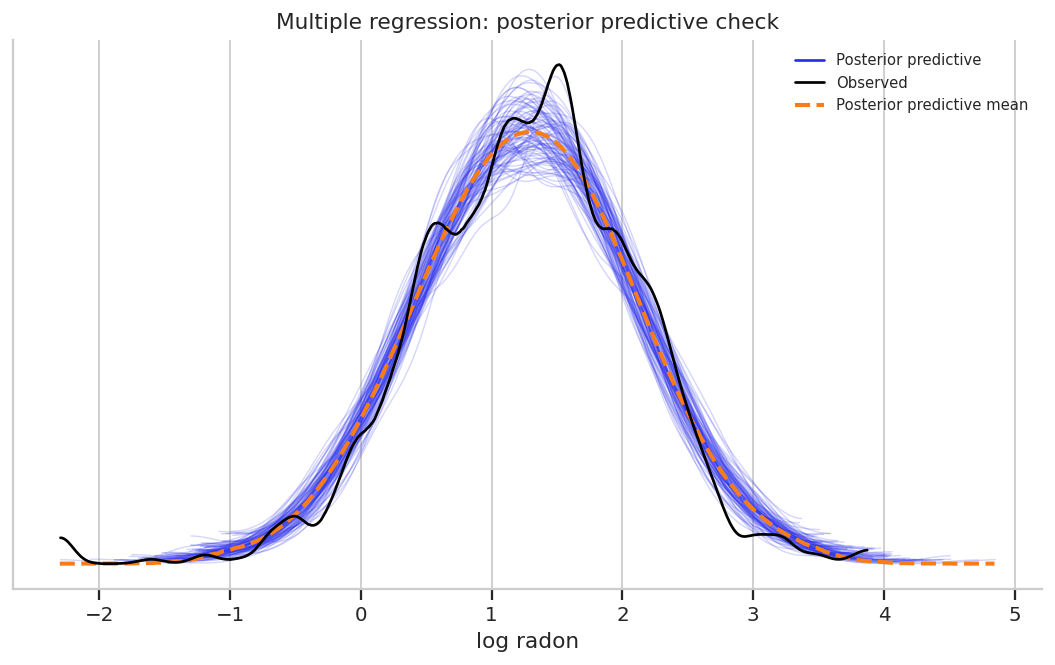

In [21]:
multiple_model.predict(idata_multiple, kind="pps", inplace=True, random_seed=RANDOM_SEED)
plot_regression_ppc(idata_multiple, title="Multiple regression: posterior predictive check", xlabel="log radon")

/tmp/ipykernel_1018/2781692638.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


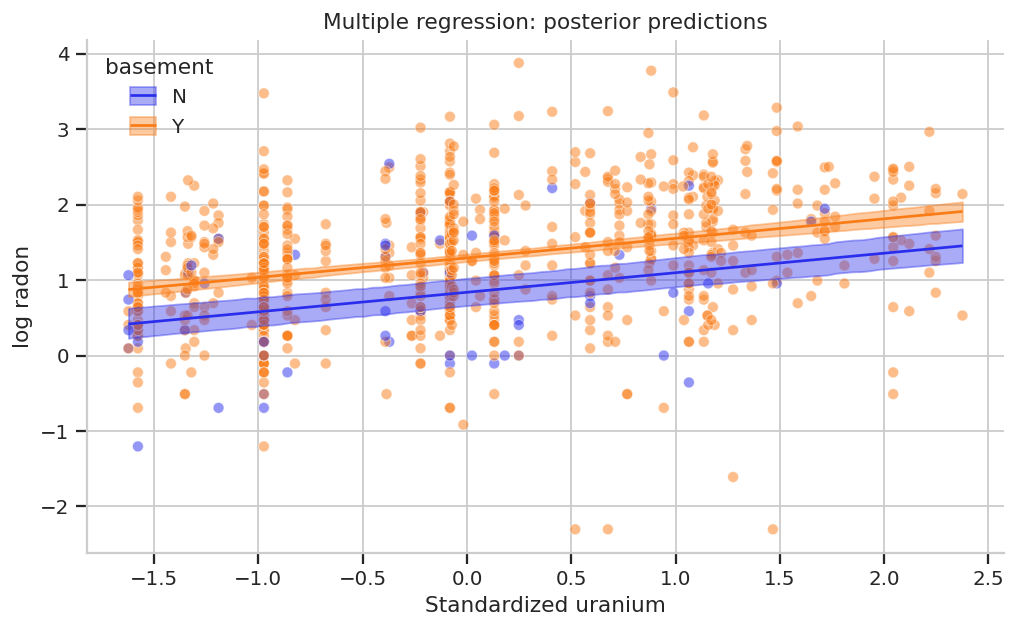

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=radon, x="uranium_z", y="log_radon", hue="basement", ax=ax, alpha=0.5)

bmb.interpret.plot_predictions(
    multiple_model,
    idata_multiple,
    conditional={
        "uranium_z": np.linspace(radon["uranium_z"].min(), radon["uranium_z"].max(), 100),
        "basement": ["N", "Y"],
    },
    ax=ax,
)

ax.set_title("Multiple regression: posterior predictions")
ax.set_xlabel("Standardized uranium")
ax.set_ylabel("log radon")
plt.tight_layout()
plt.show()

## 1.3 Model 2 — Hierarchical regression with county intercepts

Formula:

```text
log_radon ~ basement + uranium_z + (1|county)
```

Mean equation:

\[
\mu_i = \beta_0 + \beta_1 basement_i + \beta_2 uranium_{z,i} + u_{county[i]}
\]

\[
u_j \sim \operatorname{Normal}(0, \sigma_{county})
\]

Interpretation:

- `basement`: expected difference between houses with and without a basement, after accounting for uranium and county-level intercepts.
- `uranium_z`: expected change in log radon for a one-SD increase in uranium, after accounting for basement and county-level intercepts.
- `(1|county)`: a county-specific intercept. Houses from the same county share this county-level tendency.
- group-level SD: variation between county intercepts.
- `sigma`: residual variation between houses after accounting for predictors and county.

In [23]:
hierarchical_model = bmb.Model(
    "log_radon ~ basement + uranium_z + (1|county)",
    data=radon,
    family="gaussian",
    priors=radon_regression_priors,
)
print(hierarchical_model)

       Formula: log_radon ~ basement + uranium_z + (1|county)
        Family: gaussian
          Link: mu = identity
  Observations: 878
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 1.2, sigma: 1.0)
            basement ~ Normal(mu: 0.0, sigma: 1.0)
            uranium_z ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|county ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.0511))
        
        Auxiliary parameters
            sigma ~ HalfNormal(sigma: 1.0)


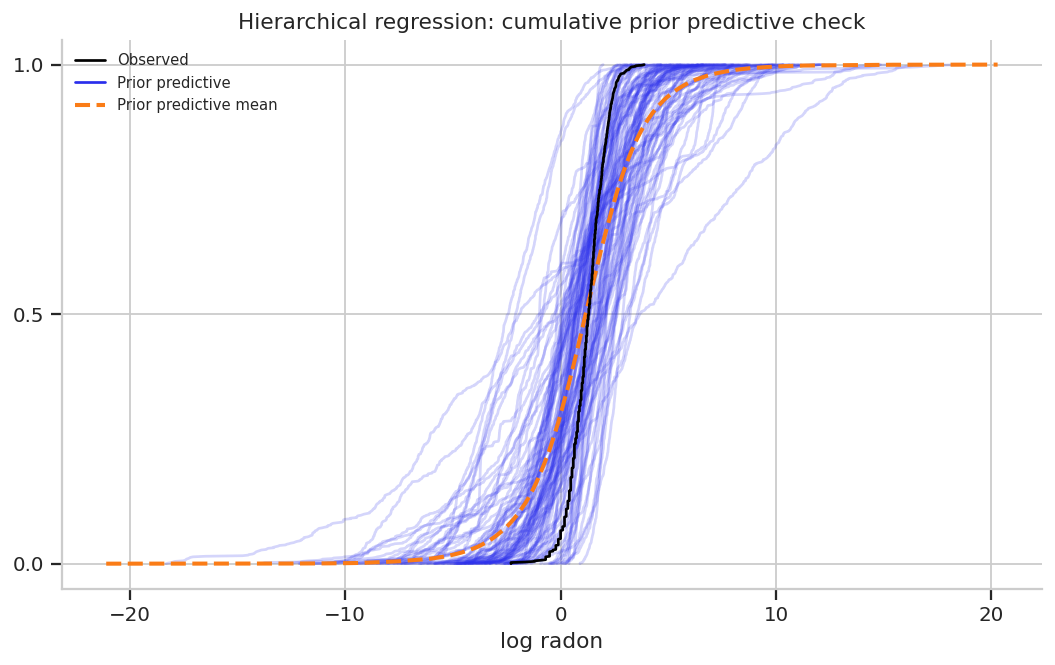

In [24]:
hierarchical_model.build()
hierarchical_prior = hierarchical_model.prior_predictive(draws=1000, random_seed=RANDOM_SEED + 1)
plot_cumulative_ppc(
    hierarchical_prior,
    group="prior",
    title="Hierarchical regression: cumulative prior predictive check",
    xlabel="log radon",
)

In [25]:
idata_hierarchical = hierarchical_model.fit(
    draws=BAYES_DRAWS,
    tune=BAYES_TUNE,
    chains=BAYES_CHAINS,
    random_seed=RANDOM_SEED + 1,
    target_accept=TARGET_ACCEPT,
    idata_kwargs={"log_likelihood": True},
)
print(idata_hierarchical)

Output()

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data


In [26]:
available_hierarchical_vars = list(idata_hierarchical.posterior.data_vars)
print(available_hierarchical_vars)

['1|county', '1|county_sigma', 'Intercept', 'basement', 'sigma', 'uranium_z']


Number of divergences in Hierarchical regression: 0


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.0,0.0,8327.0,2962.0,1.0
basement[Y],0.0,0.0,8141.0,3185.0,1.0
uranium_z,0.0,0.0,4504.0,3483.0,1.0
sigma,0.0,0.0,5643.0,2643.0,1.0


,mean,sd,hdi_3%,hdi_97%
Intercept,0.834,0.105,0.637,1.028
basement[Y],0.477,0.109,0.273,0.674
uranium_z,0.237,0.033,0.176,0.298
sigma,0.758,0.019,0.722,0.793


/tmp/ipykernel_1018/1383830446.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


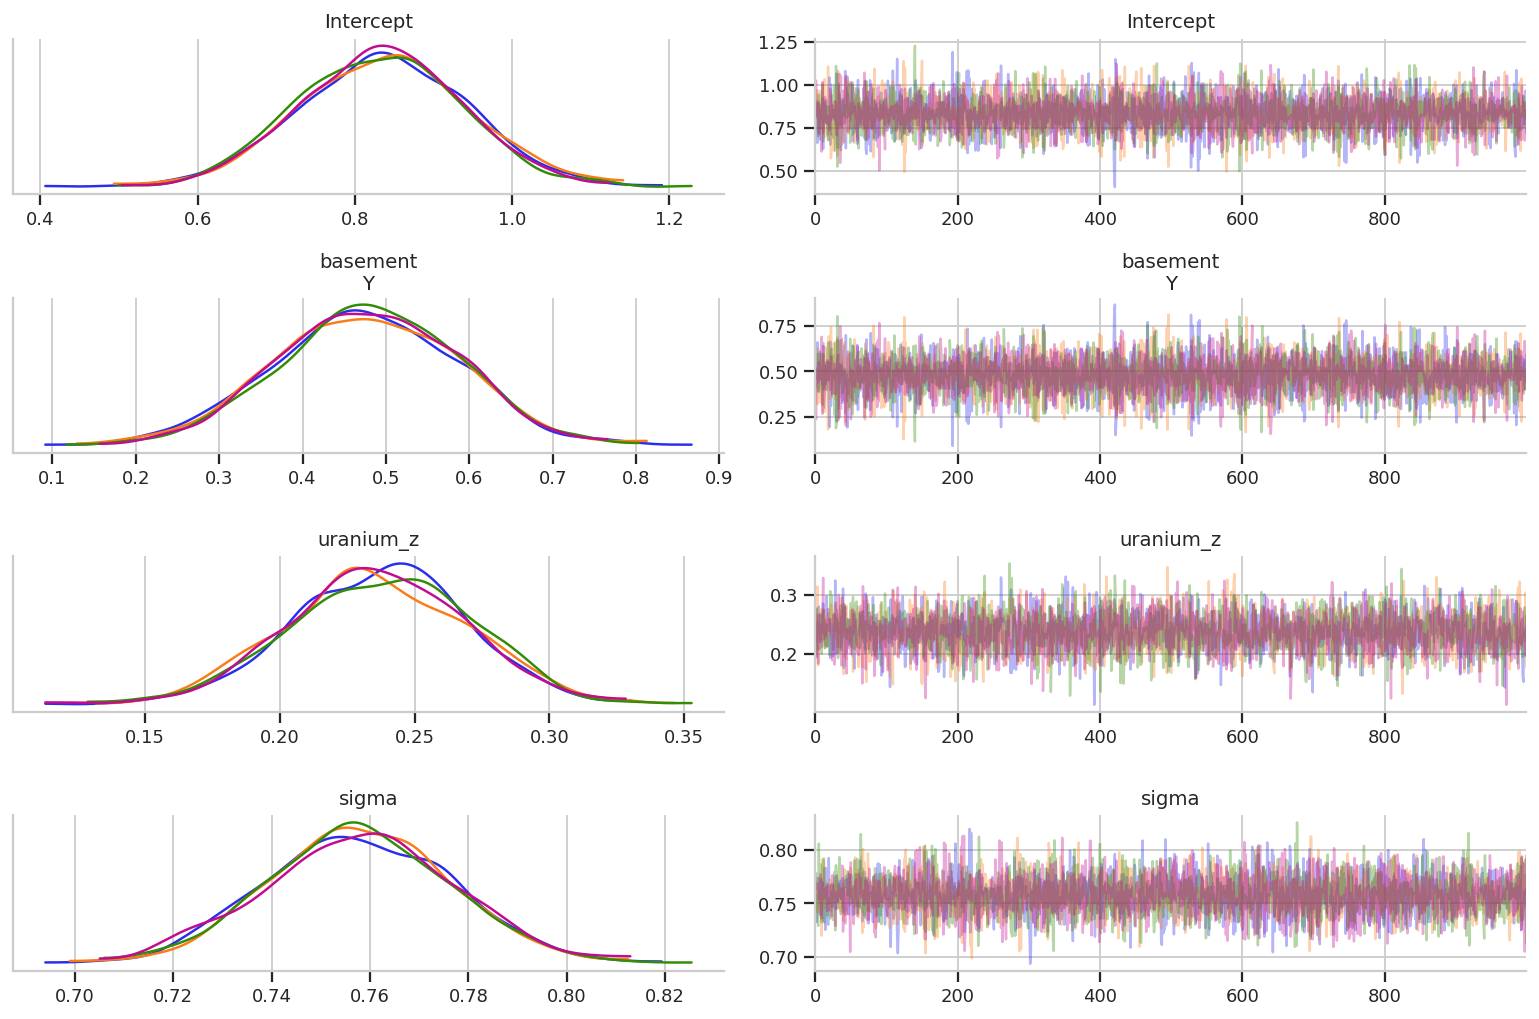

In [27]:
print_divergences(idata_hierarchical, "Hierarchical regression")

common_hierarchical_vars = ["Intercept", "basement", "uranium_z", "sigma"]

display(diagnostics_table(idata_hierarchical, var_names=common_hierarchical_vars))
display(posterior_summary_table(idata_hierarchical, var_names=common_hierarchical_vars))

az.plot_trace(idata_hierarchical, var_names=common_hierarchical_vars, compact=False)
plt.tight_layout()
plt.show()

County-level SD candidates: ['1|county_sigma']


,mean,sd,hdi_3%,hdi_97%
1|county_sigma,0.147,0.052,0.053,0.25


/tmp/ipykernel_1018/1885767930.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


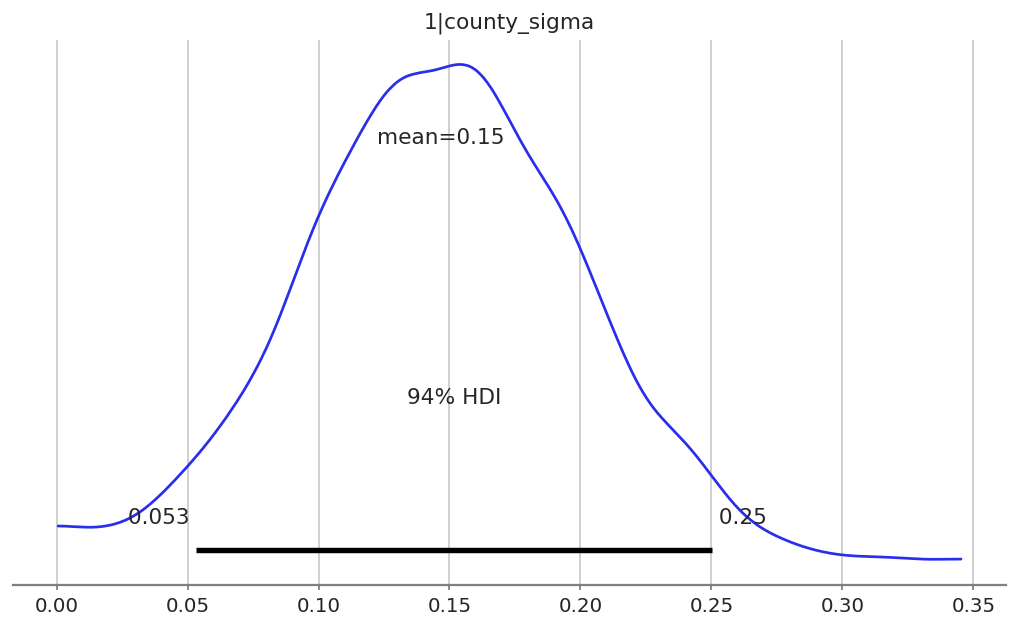

In [28]:
county_sd_candidates = [
    var_name for var_name in idata_hierarchical.posterior.data_vars
    if ("county" in var_name.lower()) and ("sigma" in var_name.lower())
]
print("County-level SD candidates:", county_sd_candidates)

if len(county_sd_candidates) > 0:
    display(posterior_summary_table(idata_hierarchical, var_names=county_sd_candidates))
    az.plot_posterior(idata_hierarchical, var_names=county_sd_candidates, hdi_prob=HDI_MASS)
    plt.tight_layout()
    plt.show()
else:
    print("No county-level SD variable was automatically identified. Inspect available_hierarchical_vars above.")

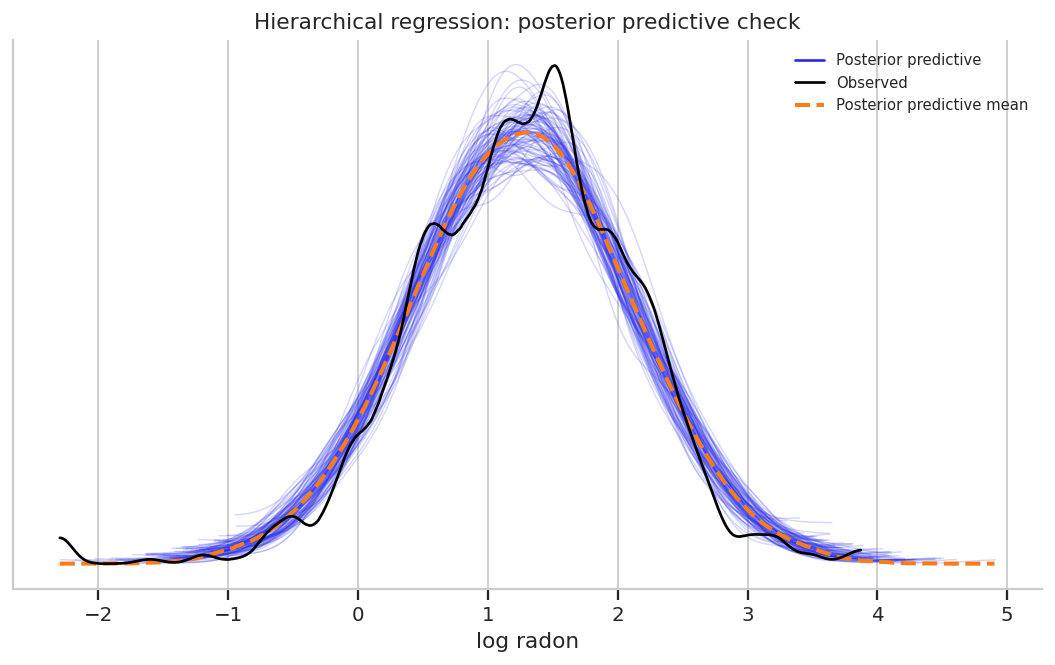

In [29]:
hierarchical_model.predict(idata_hierarchical, kind="pps", inplace=True, random_seed=RANDOM_SEED + 1)
plot_regression_ppc(idata_hierarchical, title="Hierarchical regression: posterior predictive check", xlabel="log radon")

/tmp/ipykernel_1018/193830671.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


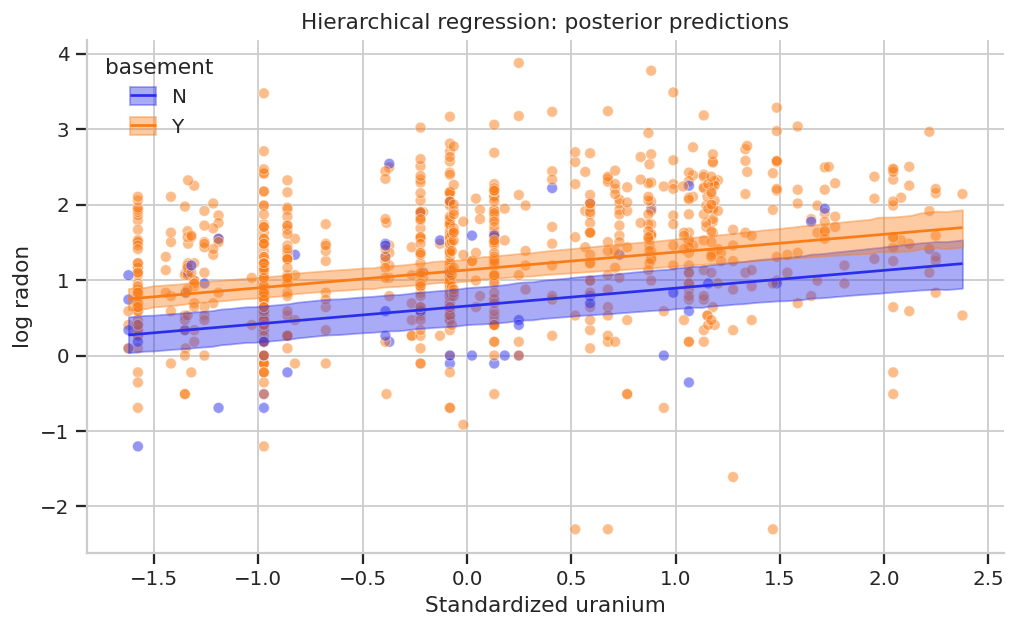

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=radon, x="uranium_z", y="log_radon", hue="basement", ax=ax, alpha=0.5)

bmb.interpret.plot_predictions(
    hierarchical_model,
    idata_hierarchical,
    conditional={
        "uranium_z": np.linspace(radon["uranium_z"].min(), radon["uranium_z"].max(), 100),
        "basement": ["N", "Y"],
    },
    ax=ax,
)

ax.set_title("Hierarchical regression: posterior predictions")
ax.set_xlabel("Standardized uranium")
ax.set_ylabel("log radon")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


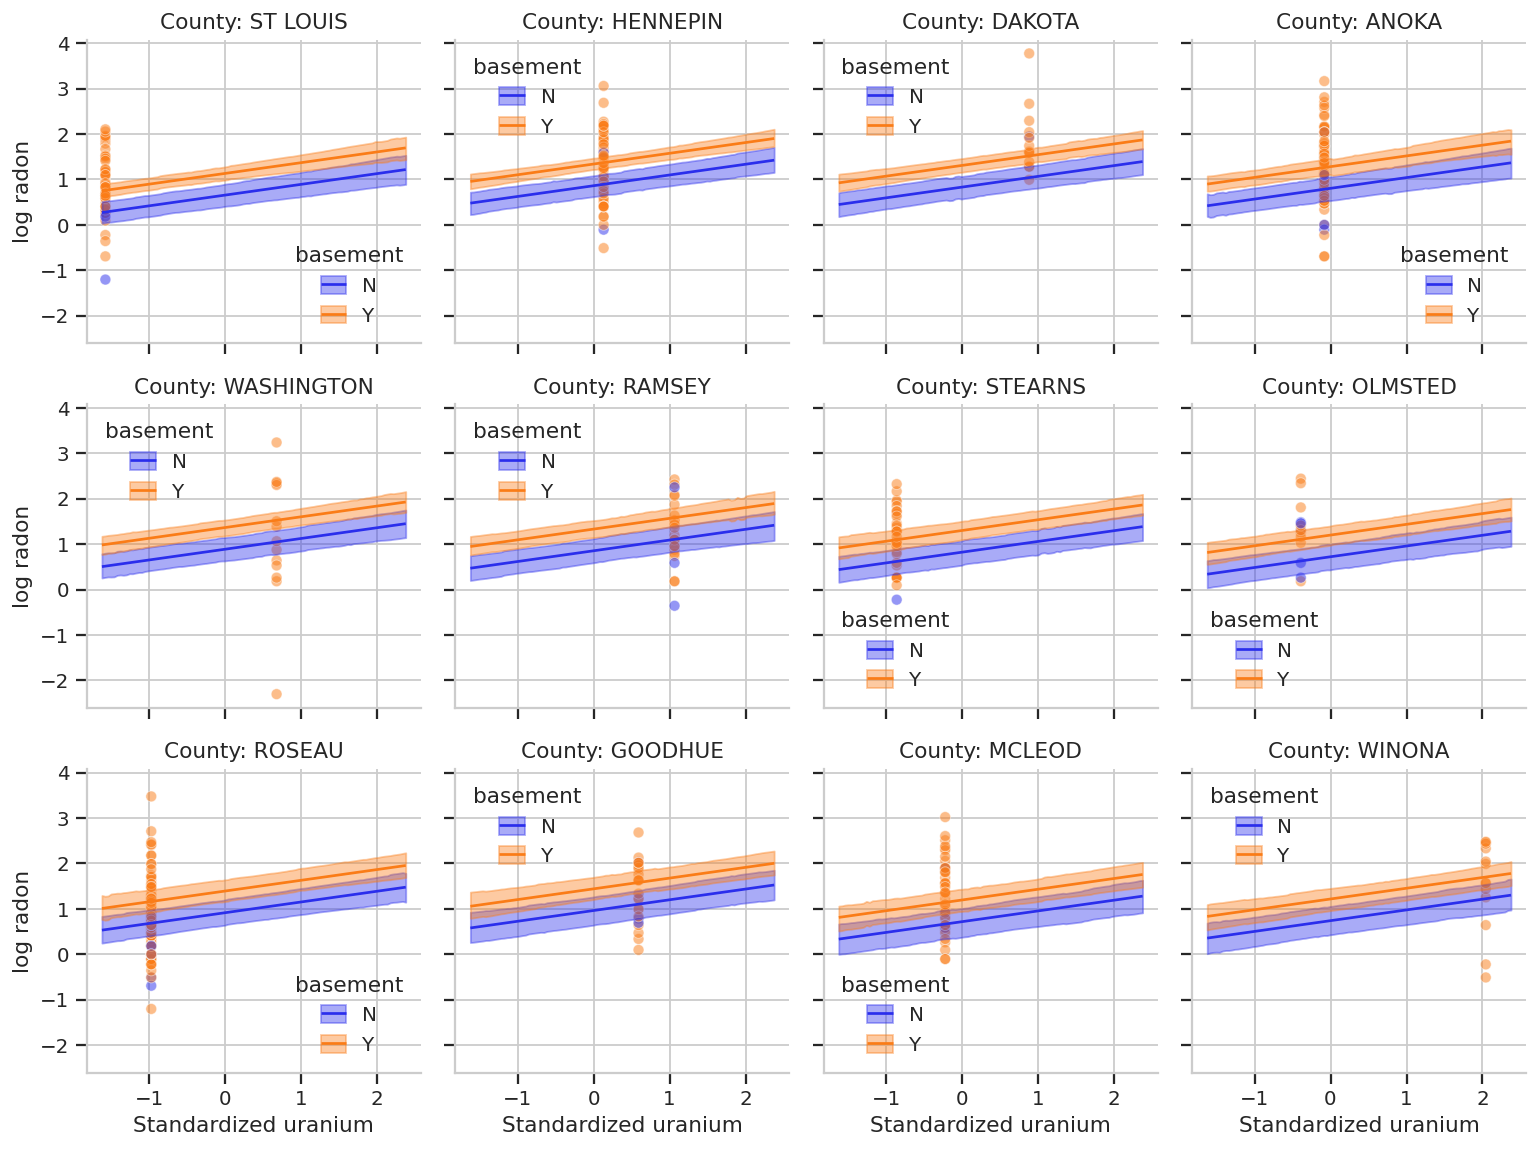

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb

# Choose counties to display
# Option 1: counties with the most observations
selected_counties = radon["county"].value_counts().head(12).index.tolist()

# Keep only selected counties
radon_subset = radon[radon["county"].isin(selected_counties)].copy()

# Create facet grid
g = sns.FacetGrid(
    radon_subset,
    col="county",
    col_wrap=4,
    height=3,
    sharex=True,
    sharey=True
)

# Plot observed data in each county
g.map_dataframe(
    sns.scatterplot,
    x="uranium_z",
    y="log_radon",
    hue="basement",
    alpha=0.5
)

# Add county-specific prediction lines
uranium_grid = np.linspace(
    radon["uranium_z"].min(),
    radon["uranium_z"].max(),
    100
)

for ax, county in zip(g.axes.flat, selected_counties):
    bmb.interpret.plot_predictions(
        hierarchical_model,
        idata_hierarchical,
        conditional={
            "uranium_z": uranium_grid,
            "basement": ["N", "Y"],   # fix basement for clarity
            "county": [county],
        },
        ax=ax,
    )

    ax.set_title(f"County: {county}")
    ax.set_xlabel("Standardized uranium")
    ax.set_ylabel("log radon")

plt.tight_layout()
plt.show()

## 1.4 Compare the regression models

We compare the two models using approximate leave-one-out cross-validation (LOO). The purpose is not to prove that one model is true. The question is whether the hierarchical model improves expected out-of-sample prediction by accounting for county-level structure.

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Hierarchical county,0,-1014.651054,24.734540,0.000000,0.843568,30.370070,0.000000,False,log
Multiple regression,1,-1017.994405,5.036798,3.343351,0.156432,30.151057,3.110345,False,log


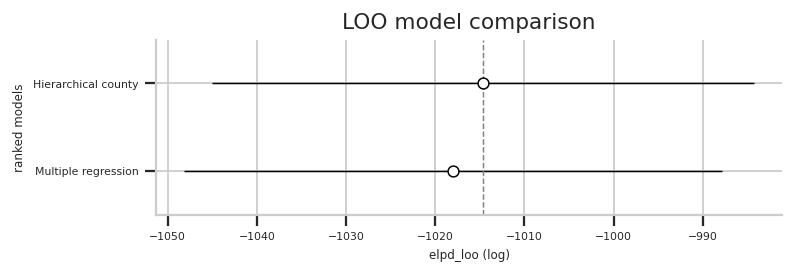

In [ ]:
model_comparison = az.compare(
    {
        "Multiple regression": idata_multiple,
        "Hierarchical county": idata_hierarchical,
    },
    ic="loo",
)

display(model_comparison)
az.plot_compare(model_comparison)
plt.title("LOO model comparison")
plt.show()

In [ ]:
comparison_vars = ["basement", "uranium_z", "sigma"]

multiple_summary = posterior_summary_table(idata_multiple, var_names=comparison_vars).reset_index()
multiple_summary.insert(0, "model", "Multiple regression")

hierarchical_summary = posterior_summary_table(idata_hierarchical, var_names=comparison_vars).reset_index()
hierarchical_summary.insert(0, "model", "Hierarchical county")

slope_comparison = pd.concat([multiple_summary, hierarchical_summary], ignore_index=True)
display(slope_comparison)

,model,index,mean,sd,hdi_3%,hdi_97%
0,Multiple regression,basement[Y],0.456,0.102,0.259,0.640
1,Multiple regression,uranium_z,0.259,0.027,0.207,0.309
2,Multiple regression,sigma,0.770,0.018,0.735,0.805
3,Hierarchical county,basement[Y],0.477,0.109,0.273,0.674
4,Hierarchical county,uranium_z,0.237,0.033,0.176,0.298
5,Hierarchical county,sigma,0.758,0.019,0.722,0.793


**Interpretation prompt.**

1. Does the hierarchical model improve expected out-of-sample prediction?
2. How does adding county-level structure change the posterior for the basement and uranium effects?
3. Is the county-level variability meaningful relative to residual house-level variability?
4. Are the diagnostics good enough to trust the posterior summaries?

# Part 2 — Correlation and covariance

A regression model is directional:

\[
y_i \sim \operatorname{Normal}(\alpha + \beta x_i, \sigma)
\]

Here \(y\) is the outcome and \(x\) is the predictor.

A correlation model is symmetric:

\[
\begin{pmatrix}
x_i \\
y_i
\end{pmatrix}
\sim
\operatorname{MVNormal}(\boldsymbol{\mu}, \Sigma)
\]

Here neither variable is privileged as the outcome. We model the two measurements jointly.

## 2.1 Inspect the association

/tmp/ipykernel_3886/3677594165.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


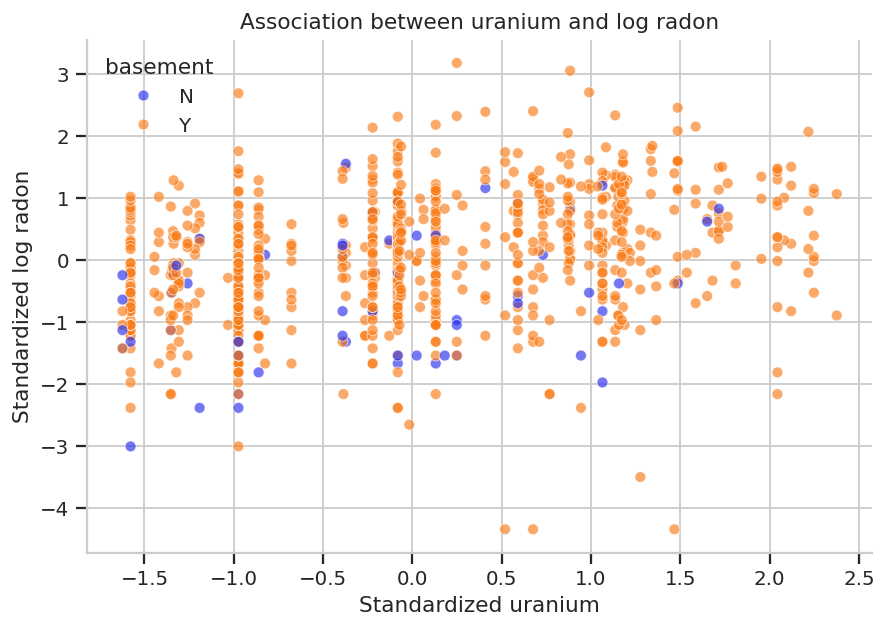

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=radon, x="uranium_z", y="log_radon_z", hue="basement", ax=ax, alpha=0.65)
ax.set_title("Association between uranium and log radon")
ax.set_xlabel("Standardized uranium")
ax.set_ylabel("Standardized log radon")
plt.tight_layout()
plt.show()

## 2.2 Pearson correlation

The sample Pearson correlation is denoted by \(r\). It estimates the population correlation \(\rho\).

\[
-1 \leq r \leq 1
\]

The frequentist function below also returns a p-value for:

\[
H_0: \rho = 0
\]

In [ ]:
pearson_r, pearson_p = stats.pearsonr(radon["uranium_z"], radon["log_radon_z"])

pearson_table = pd.DataFrame({
    "quantity": ["Pearson r", "r squared", "p-value for H0: rho = 0"],
    "value": [pearson_r, pearson_r ** 2, pearson_p],
})

display(pearson_table)

,quantity,value
0,Pearson r,3.243355e-01
1,r squared,1.051935e-01
2,p-value for H0: rho = 0,5.926686e-23


## 2.3 \(\rho\), \(\rho^2\), covariance, and the covariance matrix

\(\rho\) is the population correlation. In a Bayesian model, \(\rho\) is a parameter with a prior and posterior distribution.

\(\rho^2\) is a normalized effect-size measure: the fraction of variance shared by the two variables.

The covariance matrix for two variables is:

\[
\Sigma =
\begin{pmatrix}
\sigma_x^2 & \sigma_{xy} \\
\sigma_{xy} & \sigma_y^2
\end{pmatrix}
\]

- The diagonal contains the variance of each variable.
- The off-diagonal contains the covariance between the variables.
- The matrix is symmetric.

Correlation is normalized covariance:

\[
\rho = \frac{\sigma_{xy}}{\sigma_x\sigma_y}
\]

Therefore:

\[
\sigma_{xy} = \rho\sigma_x\sigma_y
\]

and:

\[
\Sigma =
\begin{pmatrix}
\sigma_x^2 & \rho\sigma_x\sigma_y \\
\rho\sigma_x\sigma_y & \sigma_y^2
\end{pmatrix}
\]

   log_radon basement      Uppm  county  uranium_z  log_radon_z
0   0.832909        N  0.502054  AITKIN  -1.348424    -0.525273
1   0.832909        Y  0.502054  AITKIN  -1.348424    -0.525273
2   1.098612        Y  0.502054  AITKIN  -1.348424    -0.201600
3   0.095310        Y  0.502054  AITKIN  -1.348424    -1.423797
4   1.163151        Y  0.428565   ANOKA  -1.577700    -0.122981
Empirical covariance matrix


,uranium_z,log_radon
uranium_z,1.000,0.266
log_radon,0.266,0.674


/tmp/ipykernel_3886/3501927968.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


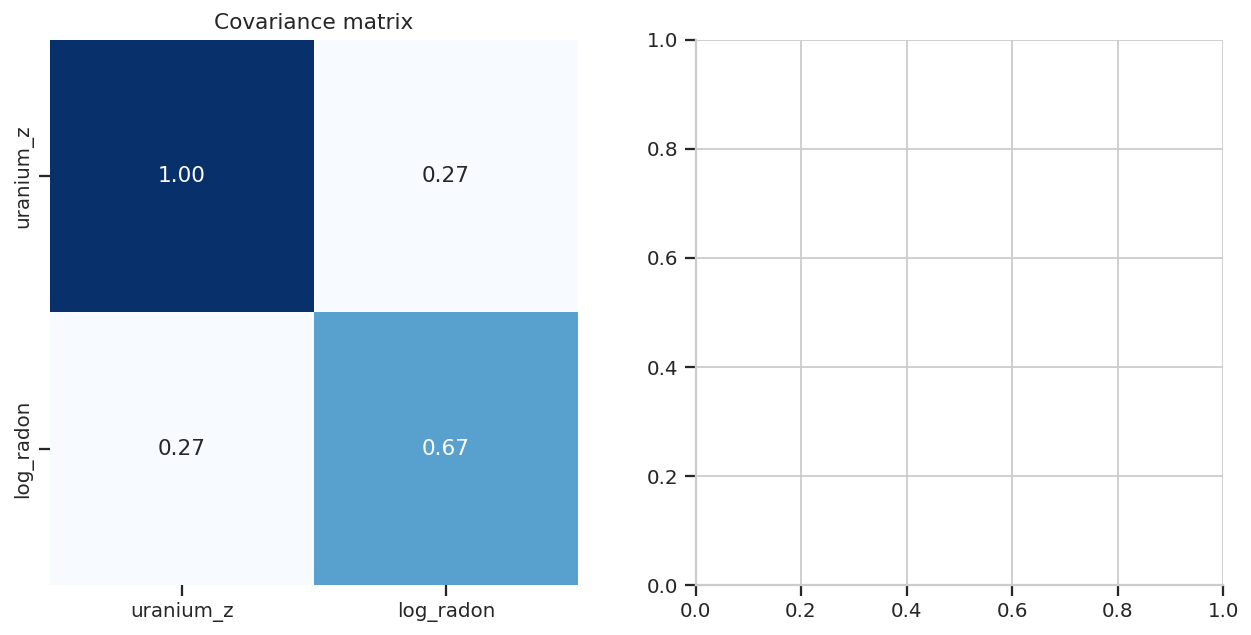

In [ ]:
print(radon.head())
correlation_data = radon[["uranium_z", "log_radon"]].copy()

print("Empirical covariance matrix")
display(correlation_data.cov().round(3))

# print("\n \n")

# print("Empirical correlation matrix")
# display(correlation_data.corr().round(3))

# plot the matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(correlation_data.cov(), ax=axes[0], cmap="Blues", annot=True, fmt=".2f", cbar=False)
axes[0].set_title("Covariance matrix")

# sns.heatmap(correlation_data.corr(), ax=axes[1], cmap="Blues", annot=True, fmt=".2f", cbar=False)
# axes[1].set_title("Correlation matrix")

plt.tight_layout()
plt.show()

## 2.4 Bayesian correlation model

To estimate \(\rho\) with Bayesian inference, \(\rho\) must appear inside the likelihood. A univariate Normal likelihood cannot do this because it models one outcome at a time. We use a bivariate Normal likelihood:

\[
\begin{pmatrix}
x_i \\
y_i
\end{pmatrix}
\sim
\operatorname{MVNormal}(\boldsymbol{\mu}, \Sigma)
\]

with:

\[
\Sigma =
\begin{pmatrix}
\sigma_x^2 & \rho\sigma_x\sigma_y \\
\rho\sigma_x\sigma_y & \sigma_y^2
\end{pmatrix}
\]

The prior for \(\rho\) is built from a transformed Beta distribution:

\[
\theta_\rho \sim \operatorname{Beta}(1.3, 1.3)
\]

\[
\rho = 2\theta_\rho - 1
\]

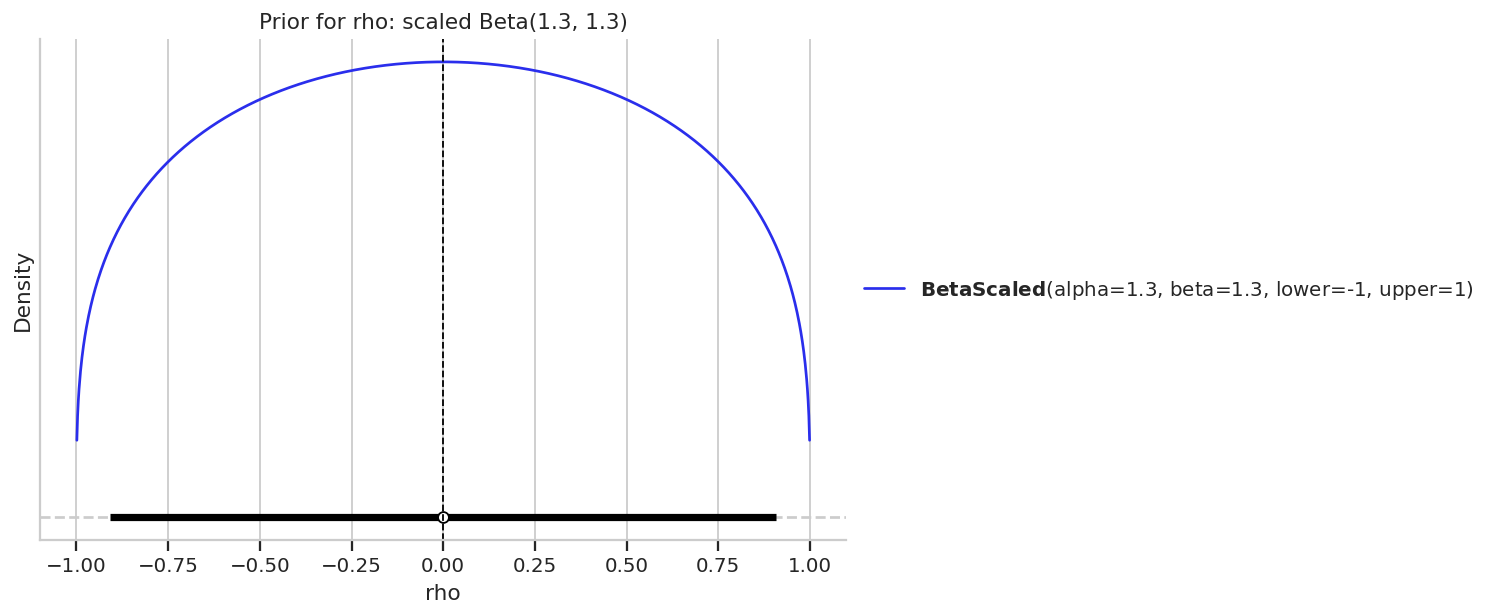

In [42]:
rho_prior = pz.BetaScaled(alpha=1.3, beta=1.3, lower=-1, upper=1)
rho_prior.plot_pdf(pointinterval=True, interval="hdi", levels=[0.95])
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Prior for rho: scaled Beta(1.3, 1.3)")
plt.xlabel("rho")
plt.ylabel("Density")
plt.show()

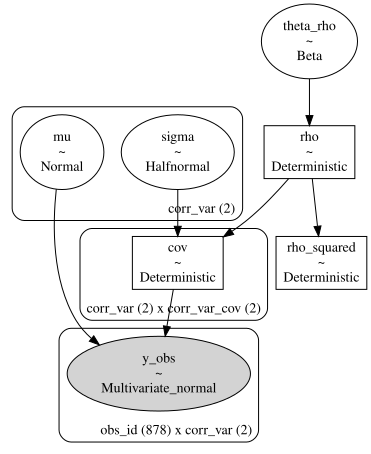

In [ ]:
xy = correlation_data.to_numpy()

coords_corr = {"obs_id": np.arange(len(xy)),
    "corr_var": ["uranium_z", "log_radon_z"],
    "corr_var_cov": ["uranium_z", "log_radon_z"],}

with pm.Model(coords=coords_corr) as correlation_model:
    mu = pm.Normal("mu", mu=0, sigma=1, dims="corr_var")
    sigma = pm.HalfNormal("sigma", sigma=1, dims="corr_var")

    theta_rho = pm.Beta("theta_rho", alpha=1.3, beta=1.3)
    rho = pm.Deterministic("rho", 2 * theta_rho - 1)
    rho_squared = pm.Deterministic("rho_squared", rho ** 2)

    cov = pm.Deterministic(
        "cov",
        pt.stack([
            pt.stack([sigma[0] ** 2, rho * sigma[0] * sigma[1]]),
            pt.stack([rho * sigma[0] * sigma[1], sigma[1] ** 2]),
        ]),
        dims=("corr_var", "corr_var_cov"))

    y_obs = pm.MvNormal(
        "y_obs",
        mu=mu,
        cov=cov,
        observed=xy,
        dims=("obs_id", "corr_var"))

pm.model_to_graphviz(correlation_model)

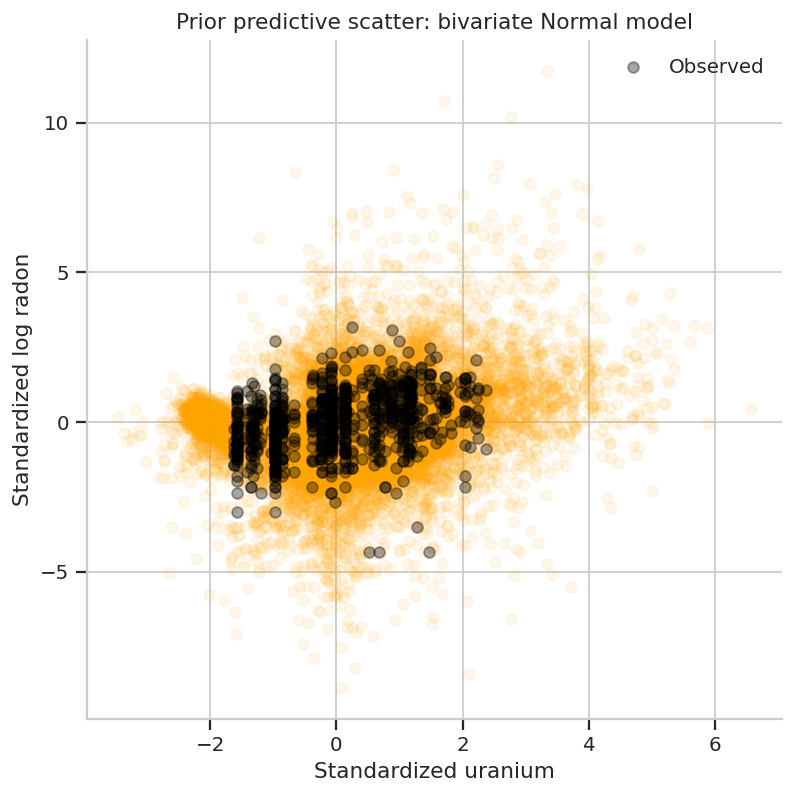

In [ ]:
with correlation_model:
    idata_corr_prior = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_SEED)

prior_pairs = (
    idata_corr_prior.prior_predictive["y_obs"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "obs_id", "corr_var")
)

fig, ax = plt.subplots(figsize=(6, 6))
n_prior_sets = min(20, prior_pairs.sizes["sample"])
for sample_idx in range(n_prior_sets):
    sample_values = prior_pairs.isel(sample=sample_idx).values
    ax.scatter(sample_values[:, 0], sample_values[:, 1], alpha=0.08, color="orange")

ax.scatter(xy[:, 0], xy[:, 1], alpha=0.35, color="black", label="Observed")
ax.set_title("Prior predictive scatter: bivariate Normal model")
ax.set_xlabel("Standardized uranium")
ax.set_ylabel("Standardized log radon")
ax.legend()
plt.show()

In [ ]:
with correlation_model:
    idata_corr = pm.sample(
        draws=BAYES_DRAWS,
        tune=BAYES_TUNE,
        chains=BAYES_CHAINS,
        random_seed=RANDOM_SEED,
        target_accept=TARGET_ACCEPT,
    )

idata_corr.extend(idata_corr_prior)
print(idata_corr)

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data


Number of divergences in Bayesian correlation model: 0


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,0.0,0.0,4045.0,3211.0,1.0
rho_squared,0.0,0.0,4045.0,3211.0,1.0
mu[uranium_z],0.0,0.0,4375.0,3482.0,1.0
mu[log_radon_z],0.0,0.0,4253.0,3165.0,1.0
sigma[uranium_z],0.0,0.0,3860.0,2777.0,1.0
sigma[log_radon_z],0.0,0.0,4290.0,3093.0,1.0


,mean,sd,hdi_3%,hdi_97%
rho,0.323,0.030,0.267,0.381
rho_squared,0.105,0.020,0.068,0.141
mu[uranium_z],-0.001,0.034,-0.063,0.062
mu[log_radon_z],0.001,0.034,-0.066,0.063
sigma[uranium_z],1.001,0.024,0.953,1.044
sigma[log_radon_z],1.001,0.024,0.955,1.045


/tmp/ipykernel_3886/4132832650.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


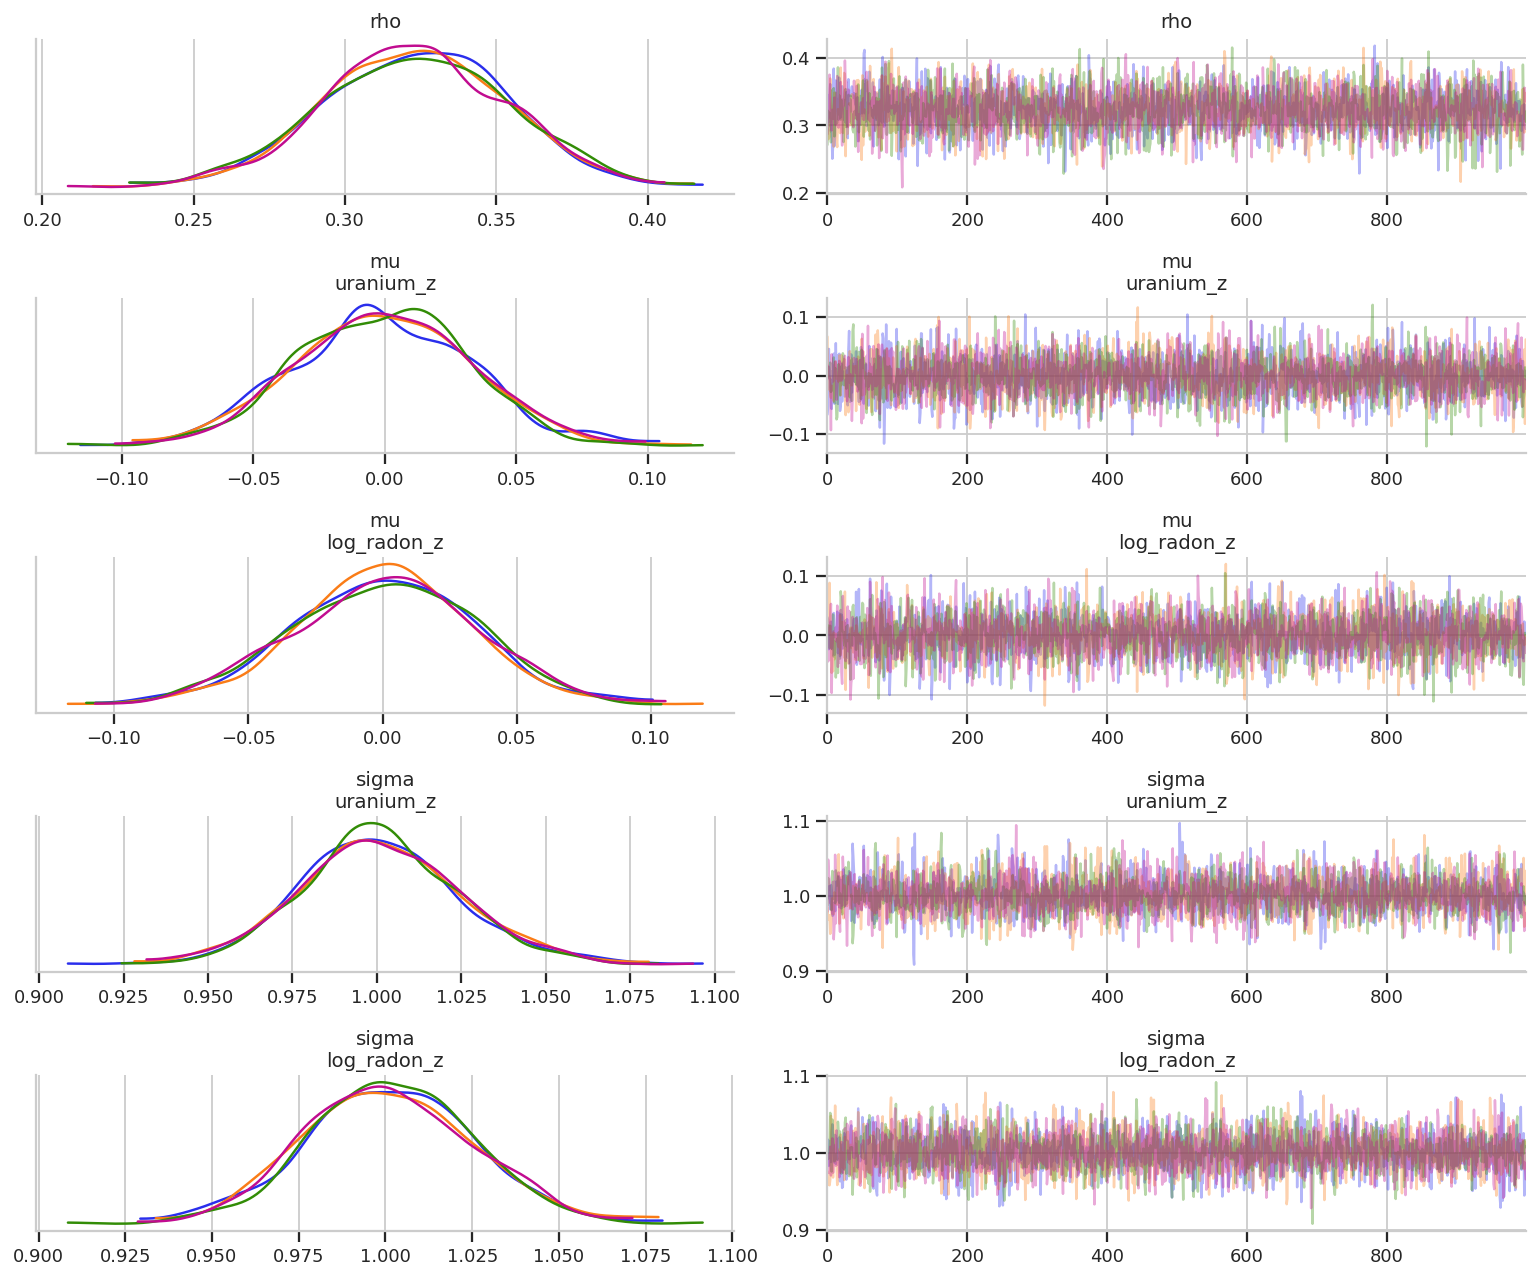

In [ ]:
print_divergences(idata_corr, "Bayesian correlation model")

display(diagnostics_table(idata_corr, var_names=["rho", "rho_squared", "mu", "sigma"]))
display(posterior_summary_table(idata_corr, var_names=["rho", "rho_squared", "mu", "sigma"]))

az.plot_trace(idata_corr, var_names=["rho", "mu", "sigma"], compact=False)
plt.tight_layout()
plt.show()

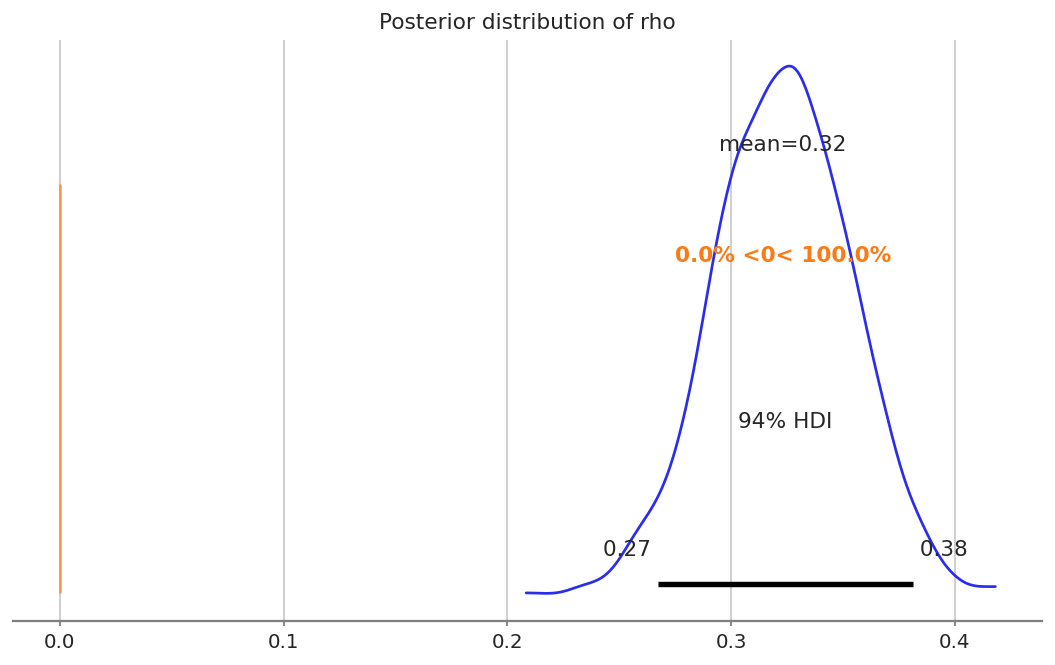

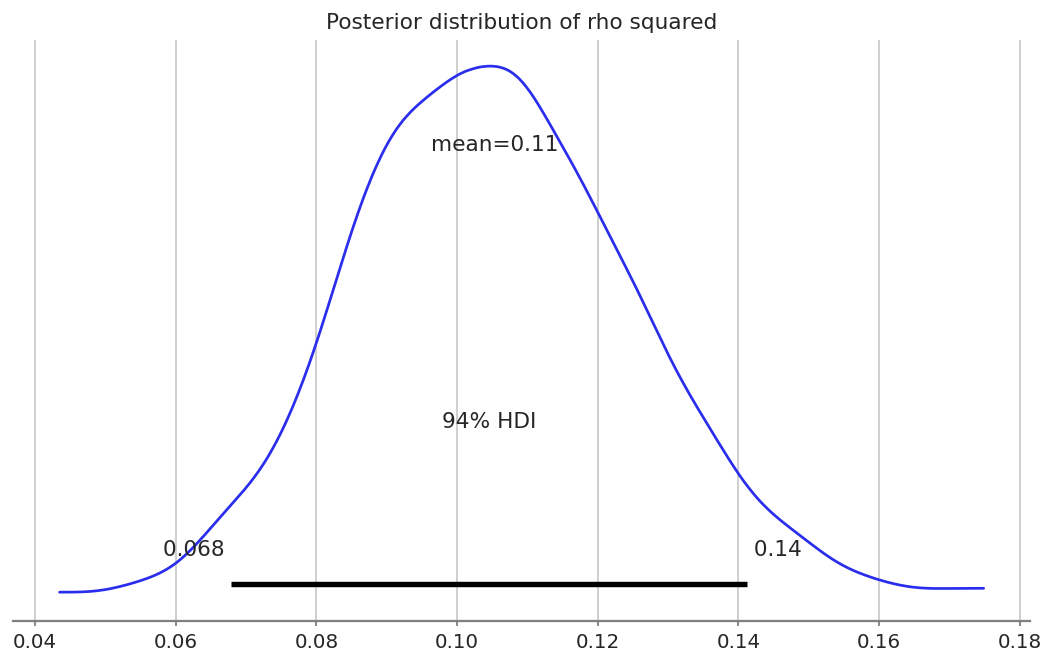

In [ ]:
az.plot_posterior(idata_corr, var_names=["rho"], hdi_prob=HDI_MASS, ref_val=0)
plt.title("Posterior distribution of rho")
plt.show()

az.plot_posterior(idata_corr, var_names=["rho_squared"], hdi_prob=HDI_MASS)
plt.title("Posterior distribution of rho squared")
plt.show()

In [ ]:
rho_samples = idata_corr.posterior["rho"].values.ravel()
rho_squared_samples = idata_corr.posterior["rho_squared"].values.ravel()

rho_hdi = az.hdi(rho_samples, hdi_prob=HDI_MASS)
rho2_hdi = az.hdi(rho_squared_samples, hdi_prob=HDI_MASS)

summary_correlation = pd.DataFrame({
    "quantity": [
        "Pearson r",
        "Posterior mean rho",
        "rho 94% HDI low",
        "rho 94% HDI high",
        "Pearson r squared",
        "Posterior mean rho squared",
        "rho squared 94% HDI low",
        "rho squared 94% HDI high",
    ],
    "value": [
        pearson_r,
        rho_samples.mean(),
        rho_hdi[0],
        rho_hdi[1],
        pearson_r ** 2,
        rho_squared_samples.mean(),
        rho2_hdi[0],
        rho2_hdi[1],
    ],
})

display(summary_correlation.round(3))

,quantity,value
0,Pearson r,0.324
1,Posterior mean rho,0.323
2,rho 94% HDI low,0.267
3,rho 94% HDI high,0.381
4,Pearson r squared,0.105
5,Posterior mean rho squared,0.105
6,rho squared 94% HDI low,0.068
7,rho squared 94% HDI high,0.141


**Interpretation prompt.**

1. Is the association positive or negative?
2. How uncertain is the estimated population correlation \(\rho\)?
3. Does \(\rho = 0\) look plausible under the posterior?
4. What does \(\rho^2\) say about shared variance?
5. How is the Bayesian answer different from reporting only Pearson's \(r\) and a p-value?

Important: this correlation model describes association. It does not by itself establish that uranium causes household radon levels. Causal interpretation would require stronger assumptions about the data-generating process.

# Final conceptual summary

This tutorial used one dataset to demonstrate two forms of dependence:

1. **Grouped dependence** — houses from the same county may be more similar than houses from different counties. A hierarchical regression represents this with county-level intercepts.
2. **Symmetric association** — two continuous measurements can co-vary without assigning one variable as the outcome and the other as the predictor. A bivariate Normal model represents this through the covariance matrix and the parameter \(\rho\).

The modeling choice depends on the scientific question:

- If the question is directional, use a regression-style model.
- If the question is symmetric association, use a correlation model.
- If observations are nested within groups, use a hierarchical structure.

In [ ]:
session_info = pd.DataFrame({
    "package": ["arviz", "bambi", "matplotlib", "numpy", "pandas", "pymc", "preliz", "scipy", "seaborn"],
    "version": [az.__version__, bmb.__version__, matplotlib.__version__, np.__version__, pd.__version__, pm.__version__, pz.__version__, scipy.__version__, sns.__version__],
})
display(session_info)

,package,version
0,arviz,0.22.0
1,bambi,0.17.2
2,matplotlib,3.10.0
3,numpy,2.0.2
4,pandas,2.2.2
5,pymc,5.28.4
6,preliz,0.24.0
7,scipy,1.16.3
8,seaborn,0.13.2
